In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler


In [2]:

# 1. TẠO DỮ LIỆU MẪU
# Tạo 300 điểm dữ liệu với 4 cụm thực tế
X, y_true = make_blobs(n_samples=300, centers=4, n_features=2,
 cluster_std=0.60, random_state=0)


In [3]:

# 2. CHUẨN HÓA DỮ LIỆU (rất quan trọng!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:

# 3. THỬ NHIỀU GIÁ TRỊ K VÀ VẼ ELBOW PLOT
wcss = [] # Within-Cluster Sum of Squares
k_range = range(1, 11)

for k in k_range:
 kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
 kmeans.fit(X_scaled)
 wcss.append(kmeans.inertia_) # inertia_ = WCSS

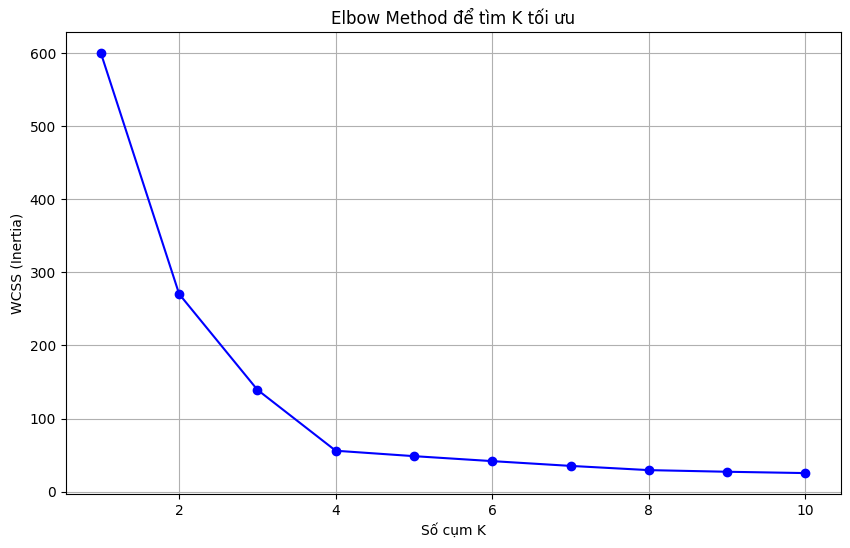

In [5]:
# Vẽ Elbow Plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Số cụm K')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method để tìm K tối ưu')
plt.grid(True)
plt.show()

In [6]:


# 4. CHỌN K TỐI ƯU VÀ PHÂN CỤM
optimal_k = 4 # Chọn dựa trên Elbow plot
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_pred = kmeans_final.fit_predict(X_scaled)


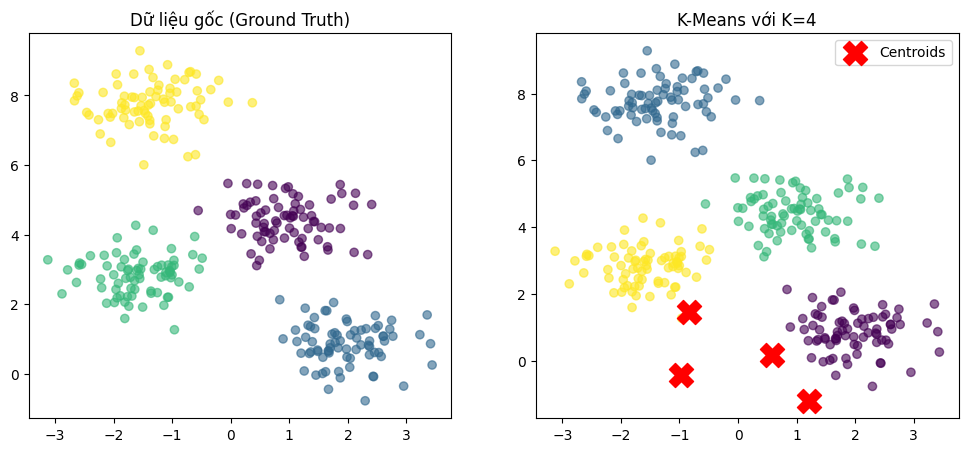

In [7]:

# 5. TRỰC QUAN HÓA KẾT QUẢ
plt.figure(figsize=(12, 5))
# Plot dữ liệu gốc
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6)
plt.title('Dữ liệu gốc (Ground Truth)')
# Plot kết quả phân cụm
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6)
plt.scatter(kmeans_final.cluster_centers_[:, 0], 
 kmeans_final.cluster_centers_[:, 1],
 s=300, c='red', marker='X', label='Centroids')
plt.title(f'K-Means với K={optimal_k}')
plt.legend()
plt.show()